In [1]:
import torch
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
sys.path.append('../')
from utilities import load_embedding, print_exams
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from IPython.display import clear_output
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

In [2]:
class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)

    return pd.DataFrame(merged_rows)

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

def monte_carlo_preds(model, dataloader, emb_dict, device, T=20):
    all_preds = []
    all_labels = []
    seed_base = 42
    model.train()
    Total_iter = T*len(dataloader)
    progress_bar = tqdm(range(Total_iter), desc="Monte Carlo Predictions")
    for t in range(T):
        for batch in dataloader:
            with torch.no_grad():
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[0]])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[1]])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[2]])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[3]])
                strainPassCats, labels = batch[4], batch[5]
                matrixs_a, matrixs_b, matrixs_c, matrixs_d= matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
                strainPassCats, labels = strainPassCats.to(device), labels.to(device)

                torch.manual_seed(seed_base + t)
                torch.cuda.manual_seed_all(seed_base + t)
                
                _, _, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
                all_preds.append([item[0].item() for item in output])
                all_labels.append(labels)
                progress_bar.update(1)
    
    progress_bar.close()
    return all_preds, all_labels


In [26]:
device = torch.device('cuda:2')
Crick_train = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/titer/train.csv', index_col=False)
Crick_test = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/titer/test.csv', index_col=False)
Active_data = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/CDC_all.csv', index_col=False)
Active_data = Active_data.loc[Active_data['virusDate'] <= '2023-08-31']

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Active_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Active_final = Active_data.groupby(group_columns).agg(agg_dict).reset_index()

Active_final['seq_id_a'] = Active_final['seq_id_a'] + '_active'
Active_final['seq_id_b'] = Active_final['seq_id_b'] + '_active'
Active_final['seq_id_c'] = Active_final['seq_id_c'] + '_active'
Active_final['seq_id_d'] = Active_final['seq_id_d'] + '_active'

Active_candidate, Active_test = train_test_split(Active_final, test_size=0.2, random_state=42)

In [4]:
print(Active_candidate.drop_duplicates(subset=['seq_a']).shape)
print(Active_test.drop_duplicates(subset=['seq_a']).shape)

(190, 22)
(178, 22)


In [23]:
batch_size = 8
Crick_train_dataloader = DataLoader(fluProfiler_Dataset(Crick_train), batch_size=batch_size, shuffle=True)
Crick_test_dataloader = DataLoader(fluProfiler_Dataset(Crick_test), batch_size=batch_size, shuffle=False)
Active_candidate_dataloader = DataLoader(fluProfiler_Dataset(Active_candidate), batch_size=batch_size, shuffle=False)
Active_test_dataloader = DataLoader(fluProfiler_Dataset(Active_test), batch_size=128, shuffle=False)

In [6]:
# load embedding
emb_dict_active = load_embedding("/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/embedding_CDC")
emb_dict_active = {key:value.to(device) for key, value in emb_dict_active.items()}

Loading tensor: 100%|██████████| 4135/4135 [03:03<00:00, 22.57file/s]


## 使用聚类筛选代表性样本

In [7]:
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in Active_candidate_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    matrixs_a, masks_a = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_d])

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
    
    test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
    test_reference_ls = test_reference_ls + labels.tolist()
    test_logits_ls.append(logits.tolist())
result = print_exams(test_prediction_ls, test_reference_ls)

MAE: 1.08840
MSE: 2.16511
pearson correlation: 0.73271
spearman correlation: 0.68265
R2_score: 0.49440


In [9]:
df = Active_candidate.copy()
df['prediction'] = test_prediction_ls
result_H1N1 = print_exams(df[df['Type'] == 'H1N1']['prediction'], df[df['Type'] == 'H1N1']['label'])
result_H3N2 = print_exams(df[df['Type'] == 'H3N2']['prediction'], df[df['Type'] == 'H3N2']['label'])

MAE: 0.85785
MSE: 1.32616
pearson correlation: 0.84701
spearman correlation: 0.48289
R2_score: 0.70845
MAE: 1.38725
MSE: 3.25263
pearson correlation: 0.53989
spearman correlation: 0.55107
R2_score: 0.01646


In [ ]:
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in Active_candidate_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    matrixs_a, masks_a = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_d])
    
    matrixs_a = matrixs_a.to(device)
    matrixs_b = matrixs_b.to(device)
    matrixs_c = matrixs_c.to(device)
    matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                    save_concat_vector='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_CDC')
    
    test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
    test_reference_ls = test_reference_ls + labels.tolist()
    test_logits_ls.append(logits.tolist())
result = print_exams(test_prediction_ls, test_reference_ls)

MAE: 1.08840
MSE: 2.16511
pearson correlation: 0.73271
spearman correlation: 0.68265
R2_score: 0.49440


In [28]:
dict_path = '/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_CDC'
files = os.listdir(dict_path)
files = sorted(files, key=lambda x: int(x.replace('.pth', '')))
my_tensors = []
for file in files:
    my_tensors.append(torch.load(os.path.join(dict_path, file), weights_only=False))
active_candidate_tensor = torch.cat(my_tensors, dim=0).cpu().numpy()
active_candidate_tensor = active_candidate_tensor[Active_candidate['Type'] == 'H3N2',]

In [29]:
active_candidate_tensor.shape

(7304, 1024)

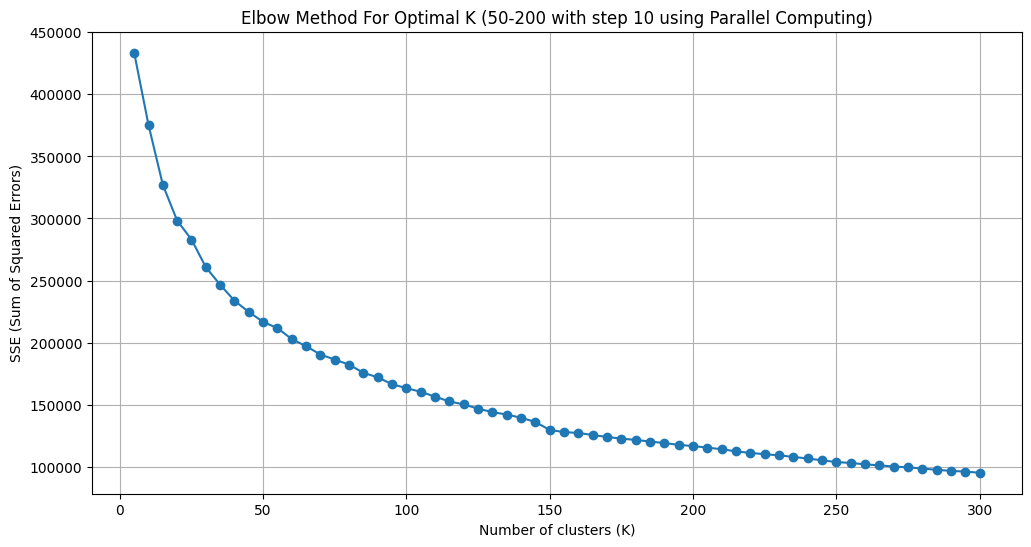

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from joblib import Parallel, delayed

# 生成示例数据
np.random.seed(42)
data = active_candidate_tensor

# 选择 K 值范围
K_min = 5
K_max = 300
step = 5  # 设置步长为10
K_range = range(K_min, K_max + 1, step)  # 从50到200，步长为10

# 并行计算每个 K 值的 SSE
def compute_sse(K):
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit(data)
    return kmeans.inertia_  # inertia_ 是每个点到其簇中心的距离平方和

# 使用 joblib 并行计算
sse = Parallel(n_jobs=-1)(delayed(compute_sse)(K) for K in K_range)

# 绘制肘部图
plt.figure(figsize=(12, 6))
plt.plot(K_range, sse, marker='o')
plt.title('Elbow Method For Optimal K (50-200 with step 10 using Parallel Computing)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.grid(True)
plt.show()

In [32]:
Active_candidate = Active_candidate.loc[Active_candidate['Type'] == 'H3N2']

In [35]:
sample_size = 500

kmeans = KMeans(n_clusters=50, random_state=42, n_init=10)
kmeans.fit(active_candidate_tensor)

Active_candidate['cluster'] = pd.Series(kmeans.labels_).tolist()

/tmp/ipykernel_3775085/2310671133.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Active_candidate['cluster'] = pd.Series(kmeans.labels_).tolist()


In [36]:
selected_cluster = pd.Series(kmeans.labels_).value_counts()
selected_cluster = selected_cluster[selected_cluster >= 5]

In [37]:
selected_cluster = pd.Series(kmeans.labels_).value_counts()
selected_cluster = selected_cluster[selected_cluster >= 5]
sample_ratio = sample_size / selected_cluster.sum()
selected_sample = Active_candidate[Active_candidate['cluster'].isin(selected_cluster.index)]

active_selection = Active_candidate.groupby('cluster', group_keys=False).apply(lambda x: x.sample(frac=sample_ratio), include_groups=False)
random_selection = Active_candidate.sample(active_selection.shape[0], random_state=42)

active_dataloader = DataLoader(fluProfiler_Dataset(active_selection), batch_size=8, shuffle=False)
random_dataloader = DataLoader(fluProfiler_Dataset(random_selection), batch_size=8, shuffle=False)

In [41]:
Active_test_dataloader = DataLoader(fluProfiler_Dataset(Active_test[Active_test['Type'] == 'H3N2']), batch_size=8, shuffle=False)

In [19]:
def multidata_trainer(model, train_dataloader, test_dataloader, emb_dict, lr_rate, epoch=15):
    model.to(device)
    no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
    weight_decay = 0.01
    beta1 = 0.9
    beta2 = 0.99
    adam_epsilon = 1e-08

    optimizer_grouped_parameters = [{
                "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
                "weight_decay": weight_decay
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
                "weight_decay": 0.0
            }
        ]
    optimizer = AdamW(optimizer_grouped_parameters,
                        lr=lr_rate,
                        betas=[beta1 if beta1 > 0 else 0.9, beta2 if beta2 > 0 else 0.98],
                        eps=adam_epsilon)


    MAE_ls = []
    MSE_ls = []
    Pearson_ls = []
    Spearman_ls = []
    for epoch in range(epoch):
        model.train()
        loss_ls = []
        for batch in train_dataloader:
            emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
            
            matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
            matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
            matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
            matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

            matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
            masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
            strainPassCats, labels = strainPassCats.to(device), labels.to(device)
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                        matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                        matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_ls.append(loss.item())
        # print('The train loss: ',np.mean(loss_ls))

        test_prediction_ls = []
        test_reference_ls = []
        test_logits_ls = []
        model.eval()
        for batch in test_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
            test_reference_ls = test_reference_ls + labels.tolist()
            test_logits_ls.append(logits.tolist())
        
        test_mae, test_mse, test_pearson, test_spearman, R2 = print_exams(test_reference_ls, test_prediction_ls)
        MAE_ls.append(test_mae)
        MSE_ls.append(test_mse)
        Pearson_ls.append(test_pearson)
        Spearman_ls.append(test_spearman)


        epochs = list(range(1, len(MSE_ls)+1))

        # 绘制折线图
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, MSE_ls, label='CDC MSE', marker='o')

        plt.text(epochs[-1], MSE_ls[-1], f'{MSE_ls[-1]:.5f}', ha='center', va='bottom')

        # 添加标题和标签
        plt.title('MSE Changes Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        clear_output(wait=True)
        plt.show()
            
    return [MAE_ls, MSE_ls, Pearson_ls, Spearman_ls, R2]

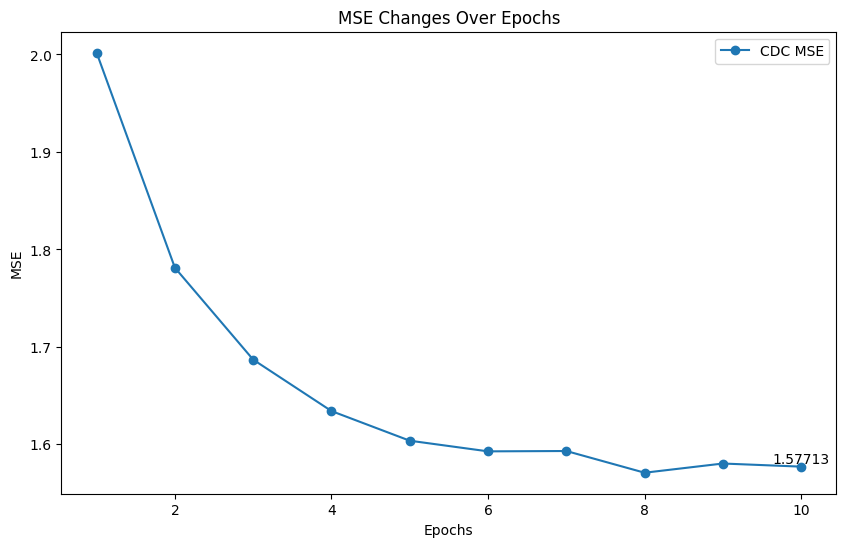

In [42]:
model_active = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
active_result = multidata_trainer(model_active, active_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=10)

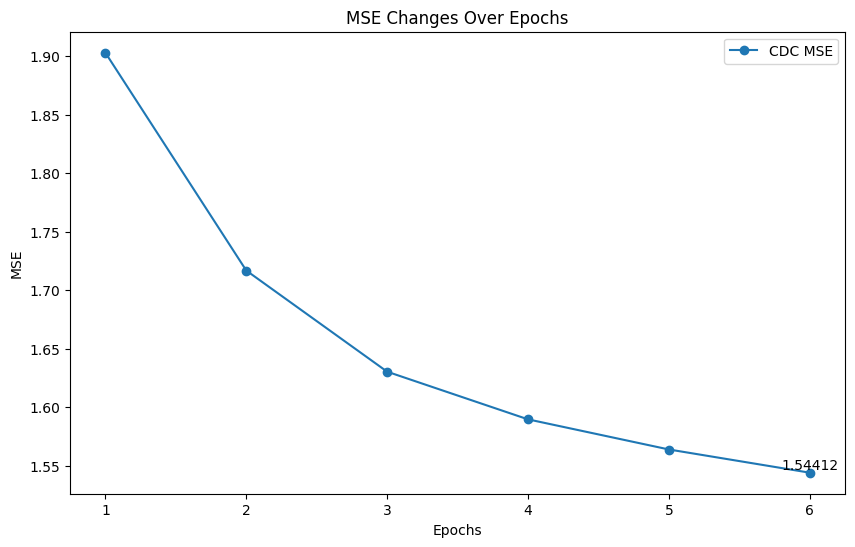

KeyboardInterrupt: 

In [43]:
model_random = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
random_result = multidata_trainer(model_random, random_dataloader, Active_test_dataloader, emb_dict_active, lr_rate=0.00004, epoch=10)

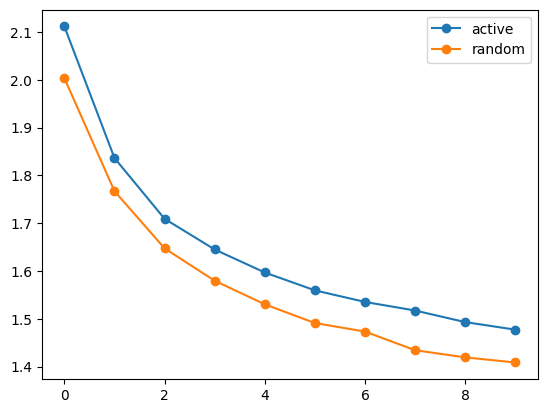

In [40]:
plt.plot(active_result[1], label='active', marker='o')
plt.plot(random_result[1], label='random', marker='o')
plt.legend()
plt.show()